# Read Database

In [2]:
# Libraries

import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [3]:
# Reading database with sqlite3

conn = sqlite3.connect('bmarket.db')

sql_query = "SELECT * FROM bank_marketing"

df = pd.read_sql(sql_query, conn)

conn.close()

df.head()

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57 years,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,Cell,2,999,no


# Initial Data Understanding and Insights

In [4]:
#
# *** Insights from running .info() ****
#
# Housing Loan and Personal Loan Columns have a lot of missing data
# Age column is of type 'object', should be changed to 'int'
#

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client ID              41188 non-null  int64 
 1   Age                    41188 non-null  object
 2   Occupation             41188 non-null  object
 3   Marital Status         41188 non-null  object
 4   Education Level        41188 non-null  object
 5   Credit Default         41188 non-null  object
 6   Housing Loan           16399 non-null  object
 7   Personal Loan          37042 non-null  object
 8   Contact Method         41188 non-null  object
 9   Campaign Calls         41188 non-null  int64 
 10  Previous Contact Days  41188 non-null  int64 
 11  Subscription Status    41188 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.8+ MB


In [5]:
#
# Check dataset for duplicates
# *** Insights ****
#
# No duplicates in data
#

print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


In [6]:
#
# Check entire dataset's data integrity
# *** Insights ****
#
# Age column can be converted to integer
# Contact Method column has 2 pairs of identical classes, can be transformed into just 1 distinct pair
# Campaign Calls has some negative values, should be all positive
#

print(list(df.columns))

for tag in list(df.columns):
    print(f"\n {tag}: {df[tag].unique()}")

['Client ID', 'Age', 'Occupation', 'Marital Status', 'Education Level', 'Credit Default', 'Housing Loan', 'Personal Loan', 'Contact Method', 'Campaign Calls', 'Previous Contact Days', 'Subscription Status']

 Client ID: [32885  3170 32207 ... 38159   861 15796]

 Age: ['57 years' '55 years' '33 years' '36 years' '27 years' '58 years'
 '48 years' '150 years' '24 years' '34 years' '42 years' '43 years'
 '26 years' '37 years' '46 years' '59 years' '49 years' '30 years'
 '51 years' '45 years' '31 years' '41 years' '38 years' '47 years'
 '69 years' '50 years' '25 years' '39 years' '44 years' '52 years'
 '35 years' '77 years' '40 years' '56 years' '53 years' '60 years'
 '29 years' '28 years' '54 years' '32 years' '81 years' '63 years'
 '21 years' '22 years' '74 years' '80 years' '62 years' '68 years'
 '86 years' '23 years' '71 years' '67 years' '65 years' '20 years'
 '19 years' '66 years' '75 years' '18 years' '72 years' '70 years'
 '82 years' '85 years' '61 years' '88 years' '83 years' '78 

Subscription Status
no     36548
yes     4640
Name: count, dtype: int64

Subscription Status
no     0.887346
yes    0.112654
Name: count, dtype: float64

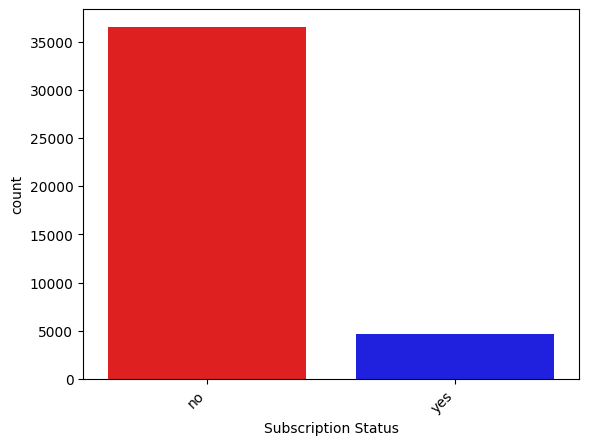

In [7]:
#
# Check data integrity and distribution of target column
# *** Insights ****
#
# Dataset is severely skewed towards non-subscribers
# Can consider SMOTE or undersampling to help balance the distribution
#

display(df['Subscription Status'].value_counts())
display(df['Subscription Status'].value_counts()/df.shape[0])
sns.countplot(data=df, x=df['Subscription Status'], hue='Subscription Status', palette={'no': 'red', 'yes': 'blue'})
plt.xticks(rotation=45, ha='right')
plt.show()

# Jade eda

In this project, I focus on three key attributes vs Subsription Status:
-Age (Numerical and optionally grouped) -Contact Method (Categorical: cellular/telephone) -Credit Default (Categorial: yes/no/unknown)

Age vs Subscription Status

In [8]:
df_eda = df.copy()

In [9]:
df_eda["Age"] = df_eda["Age"].apply(lambda x: int(x.split()[0]))

In [10]:
print("Min age:", df_eda["Age"].min())
print("Max age:", df_eda["Age"].max())

Min age: 17
Max age: 150


In [11]:
df_eda["Age"].describe()

count    41188.000000
mean        51.231572
std         34.708486
min         17.000000
25%         33.000000
50%         40.000000
75%         51.000000
max        150.000000
Name: Age, dtype: float64

In [12]:
df_eda2 = df_eda.copy()

In [13]:
median_age = df_eda2.loc[df_eda2["Age"] < 100, 'Age'].median()
df_eda2.loc[df_eda2["Age"] > 100, "Age"] = median_age

In [14]:
median_age

np.float64(38.0)

In [15]:
df_eda2["Age"].describe()

count    41188.000000
mean        39.818928
std          9.909692
min         17.000000
25%         33.000000
50%         38.000000
75%         46.000000
max         98.000000
Name: Age, dtype: float64

In [16]:
bins = [0, 29, 49, 59, 100]
labels = ['Youth', 'Adult','Middle-Aged Adults','Elderly']

df_eda2["Age_group"] = pd.cut(df_eda2['Age'], bins = bins, labels = labels)
df_eda2[["Age","Age_group"]]


,Age,Age_group
0,57,Middle-Aged Adults
1,55,Middle-Aged Adults
2,33,Adult
3,36,Adult
4,27,Youth
...,...,...
41183,58,Middle-Aged Adults
41184,37,Adult
41185,35,Adult
41186,40,Adult


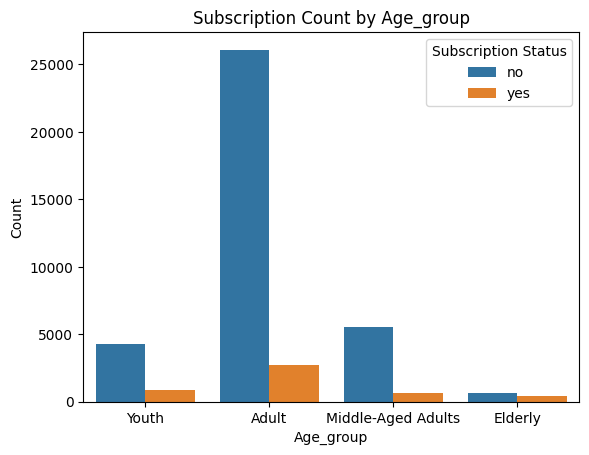

In [17]:
sns.countplot(
    data=df_eda2,
    x="Age_group",
    hue="Subscription Status"
)
plt.ylabel("Count")
plt.title("Subscription Count by Age_group")
plt.show()

Contact Method vs Subscription Status

In [18]:
df_Contact_method = df.copy()
df_Contact_method['Contact Method'] = df_Contact_method['Contact Method'].replace({'Cell': 'cellular', 'Telephone': 'telephone'})
display(df_Contact_method["Contact Method"].value_counts())
display(df_Contact_method['Contact Method'].value_counts()/df.shape[0])

Contact Method
cellular     26144
telephone    15044
Name: count, dtype: int64

Contact Method
cellular     0.634748
telephone    0.365252
Name: count, dtype: float64

Text(0.5, 1.0, 'Subscription Count by Contact Method')

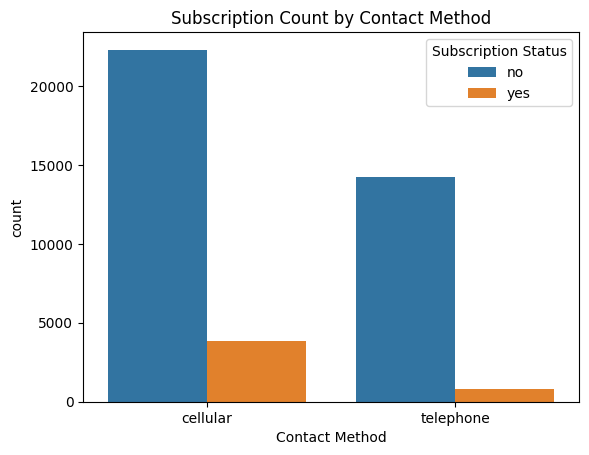

In [19]:
sns.countplot(data=df_Contact_method, x="Contact Method", hue="Subscription Status")
plt.title("Subscription Count by Contact Method")

Subscription count by Contact Method

The bar chart shows that clients contacted via **cellular** have a higher
subscription rate than those contacted via **telephone**.

This suggests that personal mobile contact is a more effective channel
for promoting term deposits compared to traditional landline calls.  
From a marketing perspective, AI-Vive-Banking should prioritise cellular
numbers when planning future campaigns.

Credit Default vs Subscription

In [20]:
df_Credit = df.copy()
display(df_Credit["Credit Default"].value_counts())
display(df_Credit['Credit Default'].value_counts()/df.shape[0])

Credit Default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Credit Default
no         0.791201
unknown    0.208726
yes        0.000073
Name: count, dtype: float64

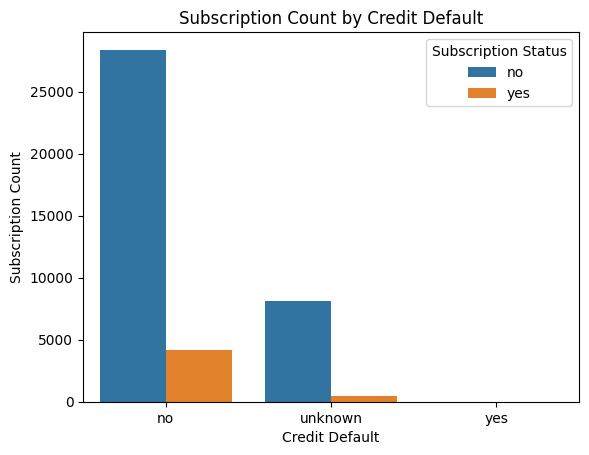

In [21]:
sns.countplot(
    data=df_Credit,
    x="Credit Default",
    hue="Subscription Status"
)
plt.ylabel("Subscription Count")
plt.title("Subscription Count by Credit Default")
plt.show()

Subscription Count by Credit Default

Most clients have `no` credit default, and this group shows the highest
subscription count.

Clients with `unknown` credit status subscribe less often. The very small
number of `yes` default cases leads to unstable statistics, but they are
generally less likely to subscribe.

This indicates that financially reliable clients are more receptive to
term deposits, while uncertain or risky profiles respond less to the
campaign.

One-hot encoding for Credit Default column

In [22]:
df_CreditDefault = df.copy()
df_CreditDefault_encoded = pd.get_dummies(df_CreditDefault, columns=['Credit Default'], drop_first=True)
df_CreditDefault_encoded

,Client ID,Age,Occupation,Marital Status,Education Level,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status,Credit Default_unknown,Credit Default_yes
0,32885,57 years,technician,married,high.school,no,yes,Cell,1,999,no,False,False
1,3170,55 years,unknown,married,unknown,yes,no,telephone,2,999,no,True,False
2,32207,33 years,blue-collar,married,basic.9y,no,no,cellular,1,999,no,False,False
3,9404,36 years,admin.,married,high.school,no,no,Telephone,4,999,no,False,False
4,14021,27 years,housemaid,married,high.school,None,no,Cell,2,999,no,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58 years,retired,married,professional.course,no,no,Telephone,2,999,no,True,False
41184,11285,37 years,management,married,university.degree,no,no,telephone,1,999,no,False,False
41185,38159,35 years,admin.,married,high.school,None,no,cellular,1,4,yes,False,False
41186,861,40 years,management,married,university.degree,None,no,telephone,2,999,no,False,False


In [23]:
df_CreditDefault_encoded['Subscription Status'] = df_CreditDefault_encoded['Subscription Status'].replace({ "no" : 0, "yes": 1 })
df_CreditDefault_encoded['Subscription Status']

0        0
1        0
2        0
3        0
4        0
        ..
41183    0
41184    0
41185    1
41186    0
41187    0
Name: Subscription Status, Length: 41188, dtype: object

<Axes: >

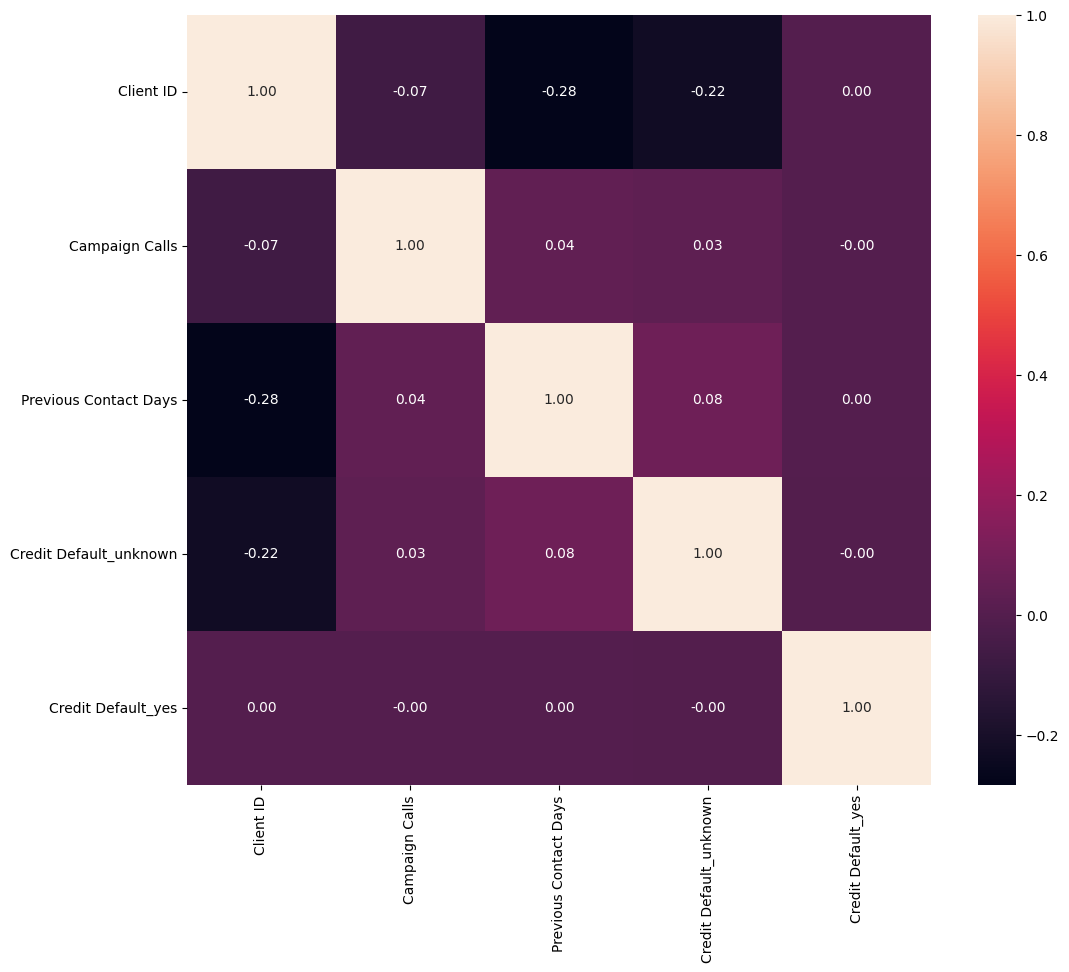

In [24]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_CreditDefault_encoded.corr(numeric_only=True), annot=True, fmt=".2f")

# Christopher: Occupation, Housing Loan, and Previous Contact Days

## Occupation

Occupation
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Occupation
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
unknown          0.008012
Name: count, dtype: float64

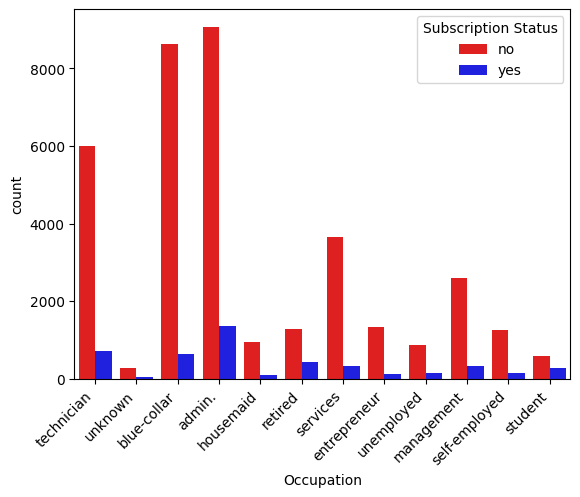

In [25]:
#
# Check data integrity and distribution
# *** Insights ****
#
# Categorical data, can be one-hot encoded
# Data skewed towards technicians, blue-collar and admin, can consider SMOTE/undersampling
#

display(df['Occupation'].value_counts())
display(df['Occupation'].value_counts()/df.shape[0])
sns.countplot(data=df, x=df['Occupation'], hue='Subscription Status', palette={'no': 'red', 'yes': 'blue'})
plt.xticks(rotation=45, ha='right')
plt.show()

In [26]:
#
# One-hot encoding for Occupation column
# 

df_Occupation = df.copy()
df_Occupation_encoded = pd.get_dummies(df_Occupation, columns=['Occupation'], drop_first=True)
df_Occupation_encoded

,Client ID,Age,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,...,Occupation_entrepreneur,Occupation_housemaid,Occupation_management,Occupation_retired,Occupation_self-employed,Occupation_services,Occupation_student,Occupation_technician,Occupation_unemployed,Occupation_unknown
0,32885,57 years,married,high.school,no,no,yes,Cell,1,999,...,False,False,False,False,False,False,False,True,False,False
1,3170,55 years,married,unknown,unknown,yes,no,telephone,2,999,...,False,False,False,False,False,False,False,False,False,True
2,32207,33 years,married,basic.9y,no,no,no,cellular,1,999,...,False,False,False,False,False,False,False,False,False,False
3,9404,36 years,married,high.school,no,no,no,Telephone,4,999,...,False,False,False,False,False,False,False,False,False,False
4,14021,27 years,married,high.school,no,None,no,Cell,2,999,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58 years,married,professional.course,unknown,no,no,Telephone,2,999,...,False,False,False,True,False,False,False,False,False,False
41184,11285,37 years,married,university.degree,no,no,no,telephone,1,999,...,False,False,True,False,False,False,False,False,False,False
41185,38159,35 years,married,high.school,no,None,no,cellular,1,4,...,False,False,False,False,False,False,False,False,False,False
41186,861,40 years,married,university.degree,no,None,no,telephone,2,999,...,False,False,True,False,False,False,False,False,False,False


In [27]:
#
# Label encoding for target column Subscription Status
# 

df_Occupation_encoded['Subscription Status'] = df_Occupation_encoded['Subscription Status'].replace({ "no" : 0, "yes": 1 })
df_Occupation_encoded['Subscription Status']

0        0
1        0
2        0
3        0
4        0
        ..
41183    0
41184    0
41185    1
41186    0
41187    0
Name: Subscription Status, Length: 41188, dtype: object

<Axes: >

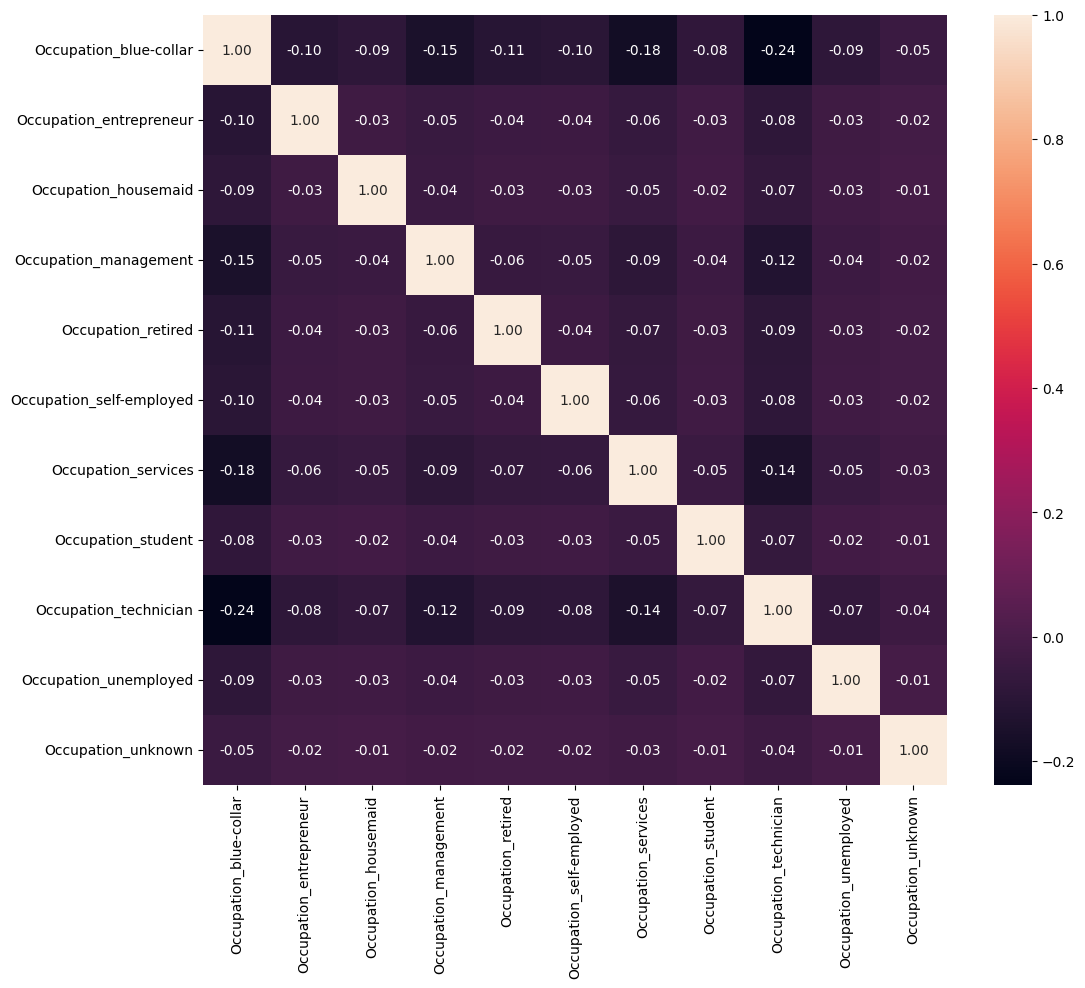

In [28]:
#
# Check correlation between Occupation types and target column
# *** Insights ****
#
# Weak linear correlation to target overall, with some types (blue collar, retired, student) having
# a slightly higher correlation
#

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_Occupation_encoded[[colname for colname in df_Occupation_encoded.columns if 'Occupation_' in colname] + ['Subscription Status']].corr(numeric_only=True), annot=True, fmt=".2f")

## Housing Loan

Housing Loan
None       24789
yes         8595
no          7411
unknown      393
Name: count, dtype: int64

Housing Loan
None       0.601850
yes        0.208677
no         0.179931
unknown    0.009542
Name: count, dtype: float64

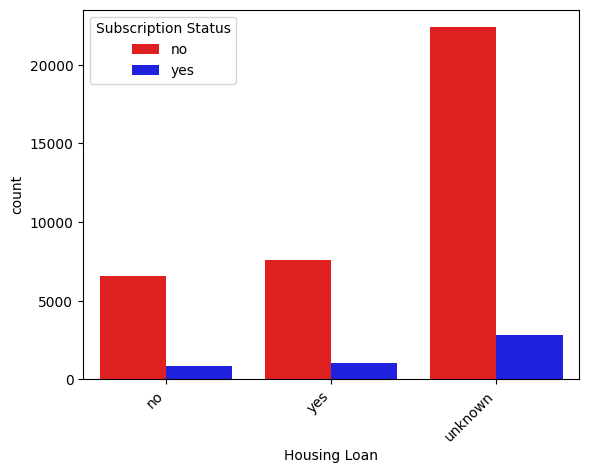

In [29]:
#
# Check data integrity and distribution
# *** Insights ****
#
# Categorical data, can be one-hot encoded
# >60% of the data is missing
# Missing data can be treated as 'unknown' due to lack of supporting information from other columns, hence making imputation unreliable
#

display(df['Housing Loan'].value_counts(dropna=False))
display(df['Housing Loan'].value_counts(dropna=False)/df.shape[0])
df_housing = df.copy()
df_housing['Housing Loan'] = df_housing['Housing Loan'].replace({ None: "unknown" })
sns.countplot(data=df_housing, x=df_housing['Housing Loan'], hue='Subscription Status', palette={'no': 'red', 'yes': 'blue'})
plt.xticks(rotation=45, ha='right')
plt.show()

In [30]:
#
# One-hot encoding for Occupation column
# 

df_housing_encoded = pd.get_dummies(df_housing, columns=['Housing Loan'])
df_housing_encoded

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status,Housing Loan_no,Housing Loan_unknown,Housing Loan_yes
0,32885,57 years,technician,married,high.school,no,yes,Cell,1,999,no,True,False,False
1,3170,55 years,unknown,married,unknown,unknown,no,telephone,2,999,no,False,False,True
2,32207,33 years,blue-collar,married,basic.9y,no,no,cellular,1,999,no,True,False,False
3,9404,36 years,admin.,married,high.school,no,no,Telephone,4,999,no,True,False,False
4,14021,27 years,housemaid,married,high.school,no,no,Cell,2,999,no,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58 years,retired,married,professional.course,unknown,no,Telephone,2,999,no,True,False,False
41184,11285,37 years,management,married,university.degree,no,no,telephone,1,999,no,True,False,False
41185,38159,35 years,admin.,married,high.school,no,no,cellular,1,4,yes,False,True,False
41186,861,40 years,management,married,university.degree,no,no,telephone,2,999,no,False,True,False


In [31]:
#
# Label encoding for target column Subscription Status
# 

df_housing_encoded['Subscription Status'] = df_housing_encoded['Subscription Status'].replace({ "no" : 0, "yes": 1 })
df_housing_encoded['Subscription Status']

0        0
1        0
2        0
3        0
4        0
        ..
41183    0
41184    0
41185    1
41186    0
41187    0
Name: Subscription Status, Length: 41188, dtype: object

<Axes: >

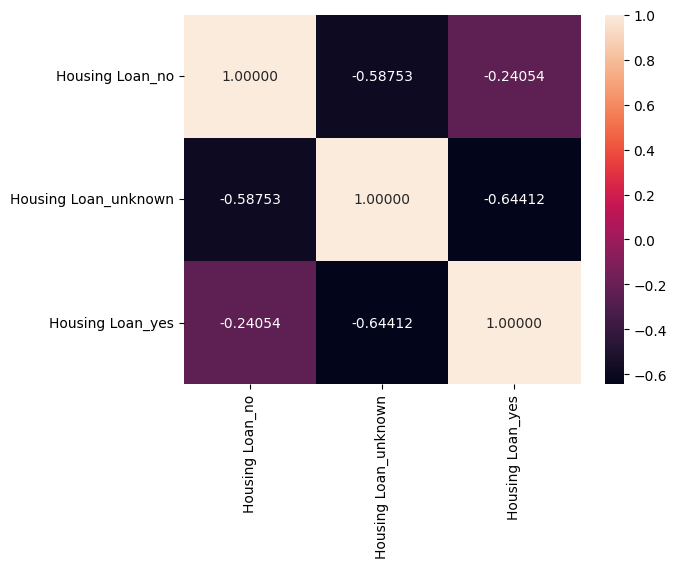

In [32]:
#
# Check correlation between Housing loan and target column
# *** Insights ****
#
# Little to no linear correlation to target
#

sns.heatmap(df_housing_encoded[[colname for colname in df_housing_encoded.columns if 'Housing Loan_' in colname] + ['Subscription Status']].corr(numeric_only=True), annot=True, fmt=".5f")

## Previous Contact Days

Previous Contact Days
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
19         3
22         3
21         2
26         1
27         1
20         1
25         1
Name: count, dtype: int64

Previous Contact Days
999    0.963217
3      0.010658
6      0.010003
4      0.002865
9      0.001554
2      0.001481
7      0.001457
12     0.001408
10     0.001263
5      0.001117
13     0.000874
11     0.000680
1      0.000631
15     0.000583
14     0.000486
8      0.000437
0      0.000364
16     0.000267
17     0.000194
18     0.000170
19     0.000073
22     0.000073
21     0.000049
26     0.000024
27     0.000024
20     0.000024
25     0.000024
Name: count, dtype: float64

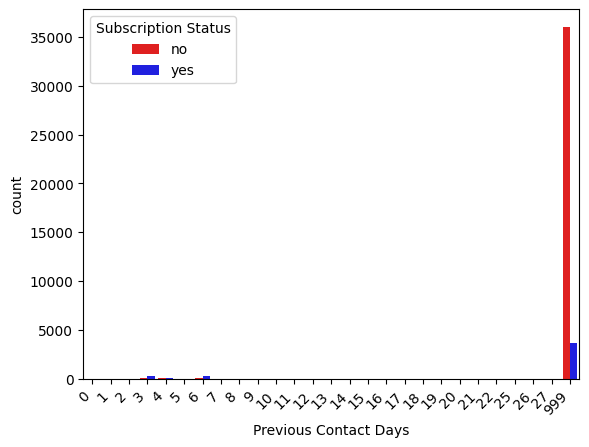

In [33]:
#
# Check data integrity and distribution
# *** Insights ****
#
# >96% of the entries are 999, highly skewed data
# 

display(df['Previous Contact Days'].value_counts())
display(df['Previous Contact Days'].value_counts()/df.shape[0])

sns.countplot(data=df, x=df['Previous Contact Days'], hue='Subscription Status', palette={'no': 'red', 'yes': 'blue'})
plt.xticks(rotation=45, ha='right')
plt.show()

Contacted
False    39673
True      1515
Name: count, dtype: int64

Contacted
False    0.963217
True     0.036783
Name: count, dtype: float64

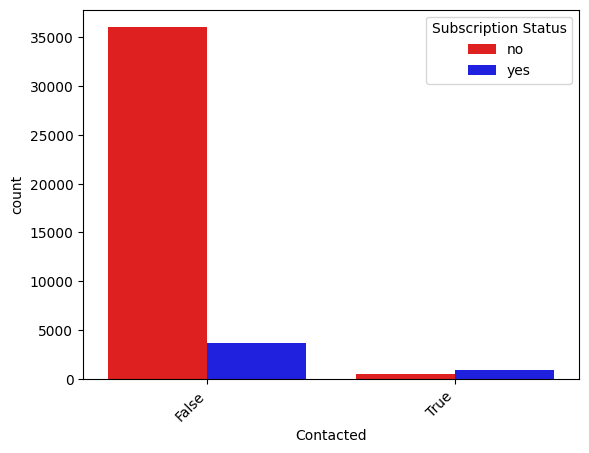

In [34]:
#
# Group according to who was contacted, and compare ratio of subscription status between those contacted and those not contacted
# *** Insights ****
#
# Those who were contacted has a slightly higher proportion of subscribers than non-subscribers
# Those who were not contacted had a significantly lower proportion of subscribers than non-subscribers
# Contacting customers makes them more likely to subscribe
# 

df_Contacted = df.copy()
df_Contacted['Contacted'] = df_Contacted['Previous Contact Days'] != 999

display(df_Contacted['Contacted'].value_counts())
display(df_Contacted['Contacted'].value_counts()/df.shape[0])

sns.countplot(data=df_Contacted, x=df_Contacted['Contacted'], hue='Subscription Status', palette={'no': 'red', 'yes': 'blue'})
plt.xticks(rotation=45, ha='right')
plt.show()

# Yik Heng: Marital Status, Personal Loan, Campaign Calls

## Correlation Coefficient

Label encoding below

In [35]:
labelencoder = LabelEncoder()

df_label_encoded = df.copy()
df_label_encoded.drop(columns=["Client ID"], inplace=True)
df_label_encoded["Age"] = df_label_encoded["Age"].apply(lambda x: int(x.split()[0]))
str_columns = df.select_dtypes(include=['object']).columns.tolist()

for col in str_columns:
    df_label_encoded[col] = labelencoder.fit_transform(df_label_encoded[col])

df_label_encoded

,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,40,9,1,3,0,0,2,0,1,999,0
1,38,11,1,7,1,2,0,3,2,999,0
2,16,1,1,2,0,0,0,2,1,999,0
3,19,0,1,3,0,0,0,1,4,999,0
4,10,3,1,3,0,3,0,0,2,999,0
...,...,...,...,...,...,...,...,...,...,...,...
41183,41,5,1,5,1,0,0,1,2,999,0
41184,20,4,1,6,0,0,0,3,1,999,0
41185,18,0,1,3,0,3,0,2,1,4,1
41186,23,4,1,6,0,3,0,3,2,999,0


<Axes: >

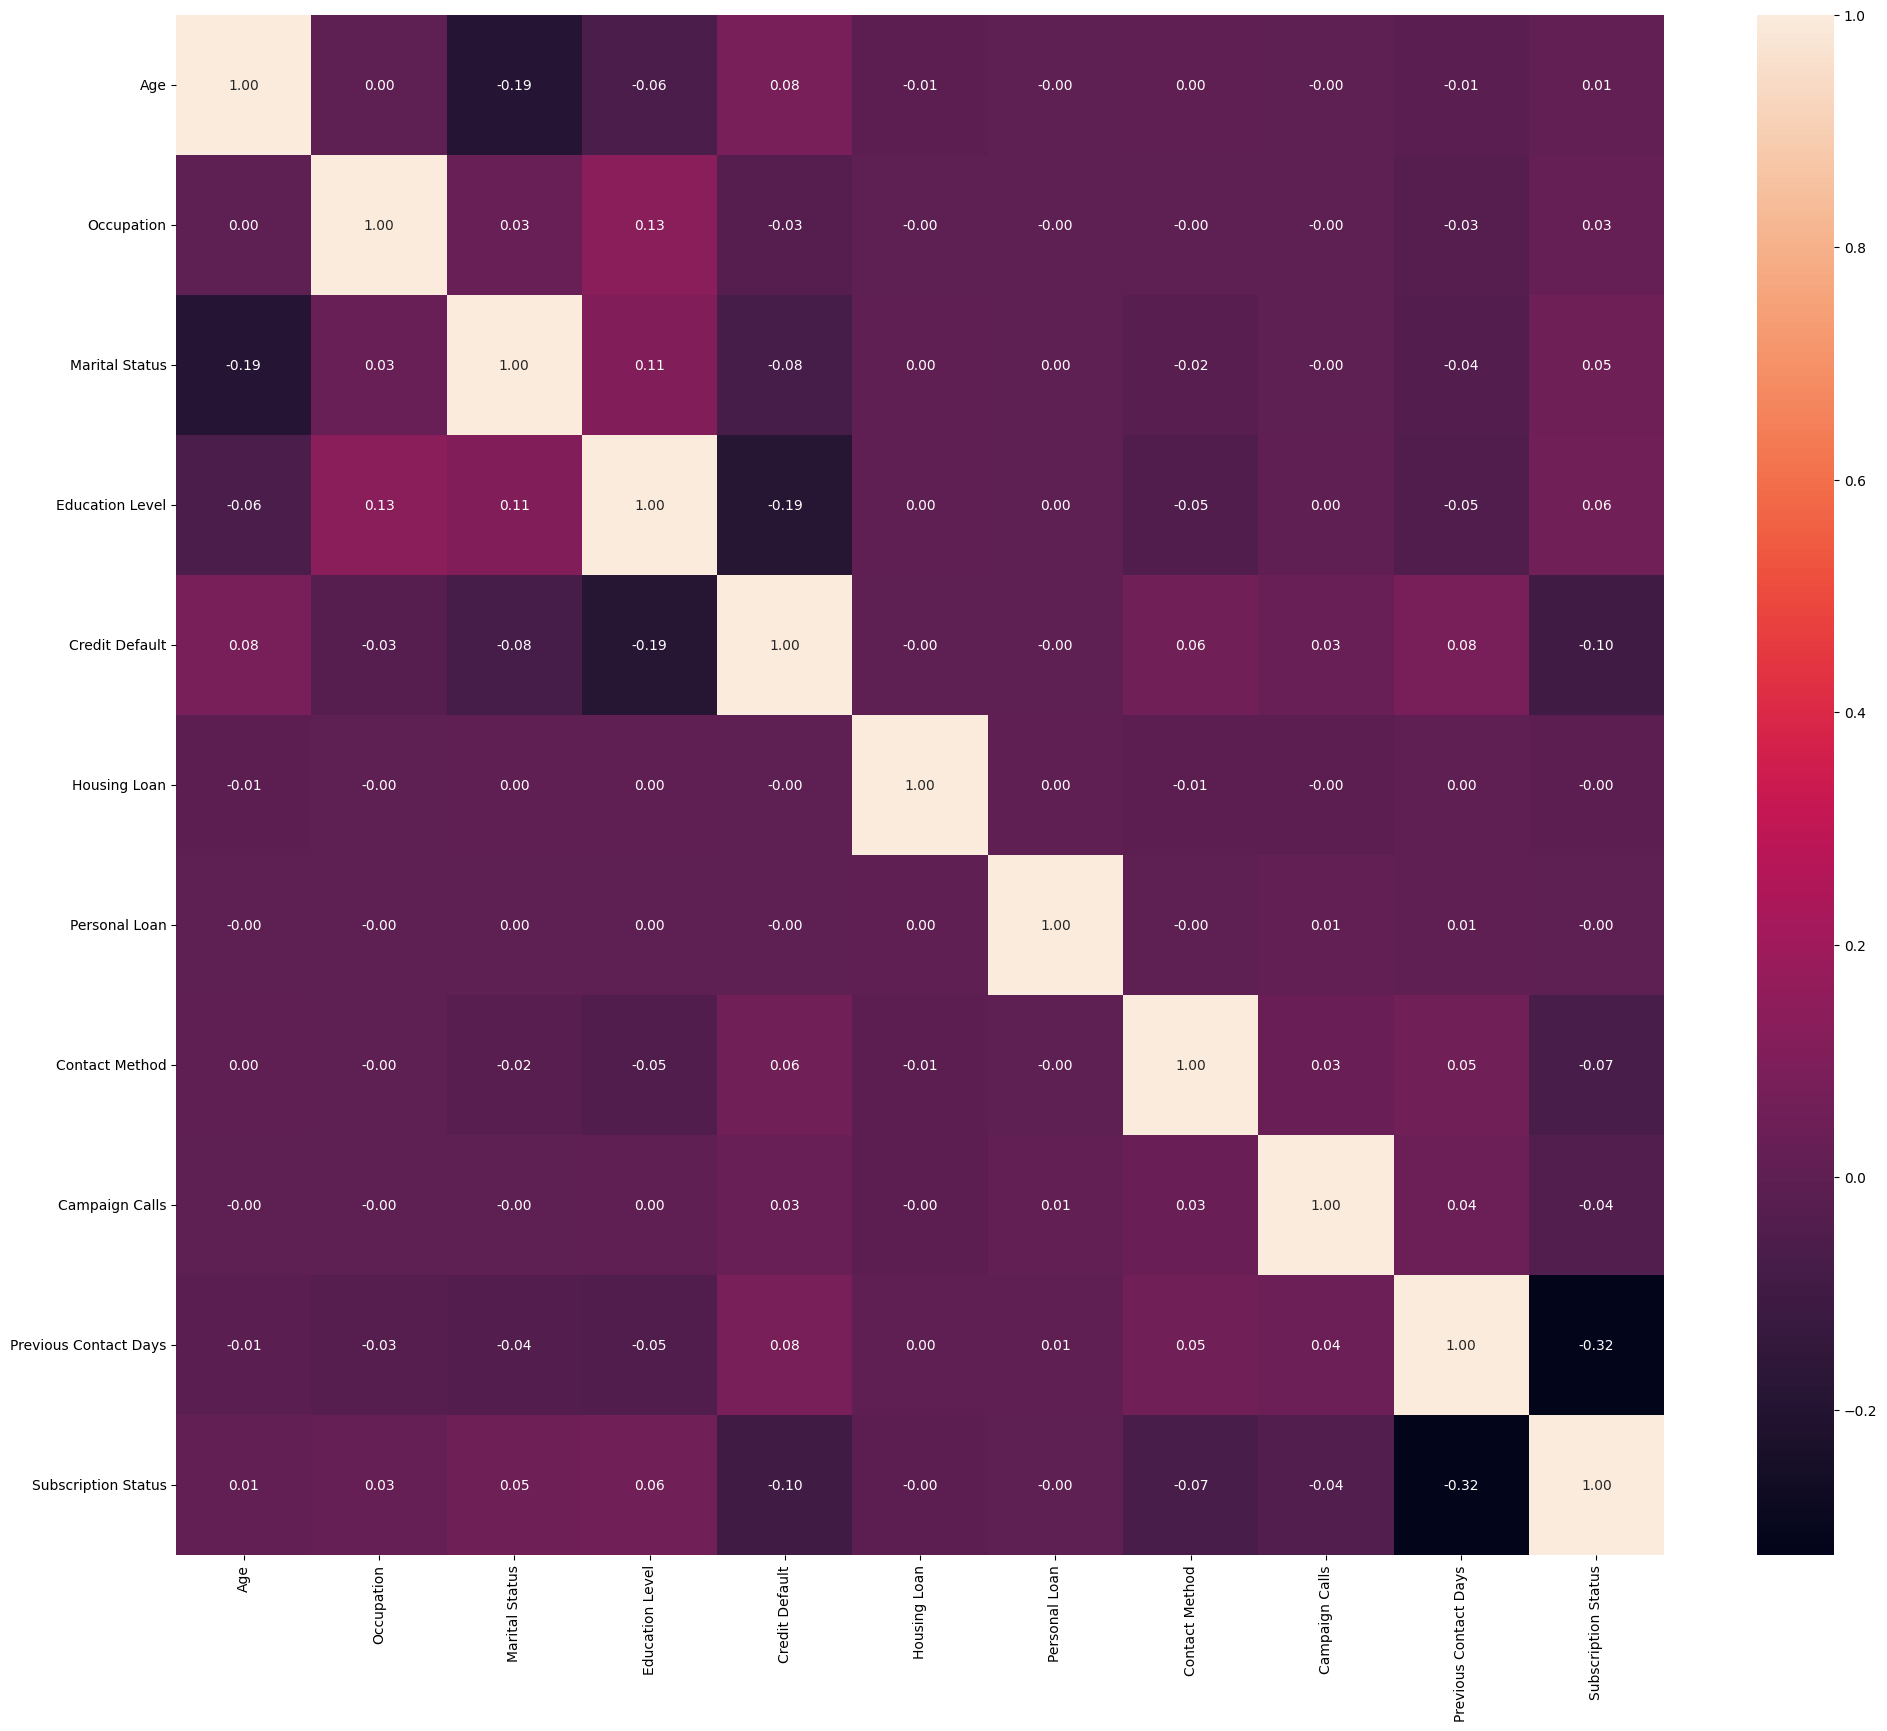

In [36]:
fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(df_label_encoded.corr(numeric_only=True), annot=True, fmt=".2f")

One hot encoder below

In [37]:
str_columns = df.select_dtypes(include=['object']).columns.tolist()
df_onehot = pd.get_dummies(df, columns=str_columns, drop_first=True)
df_onehot['Subscription Status'] = df['Subscription Status'].replace({ "no" : 0, "yes": 1 }).astype(int)
df_onehot

,Client ID,Campaign Calls,Previous Contact Days,Age_17 years,Age_18 years,Age_19 years,Age_20 years,Age_21 years,Age_22 years,Age_23 years,...,Credit Default_yes,Housing Loan_unknown,Housing Loan_yes,Personal Loan_unknown,Personal Loan_yes,Contact Method_Telephone,Contact Method_cellular,Contact Method_telephone,Subscription Status_yes,Subscription Status
0,32885,1,999,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,0
1,3170,2,999,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,0
2,32207,1,999,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,0
3,9404,4,999,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,0
4,14021,2,999,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,2,999,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,0
41184,11285,1,999,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
41185,38159,1,4,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,1
41186,861,2,999,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0


## Marital Status

In [38]:
df_encoded_marital_status = df_onehot.drop(columns=[col for col in df_onehot.columns if 'Marital Status_' not in col])
df_encoded_marital_status = pd.concat([df_encoded_marital_status, df_onehot['Subscription Status']], axis=1)
df_encoded_marital_status

,Marital Status_married,Marital Status_single,Marital Status_unknown,Subscription Status
0,True,False,False,0
1,True,False,False,0
2,True,False,False,0
3,True,False,False,0
4,True,False,False,0
...,...,...,...,...
41183,True,False,False,0
41184,True,False,False,0
41185,True,False,False,1
41186,True,False,False,0


<Axes: >

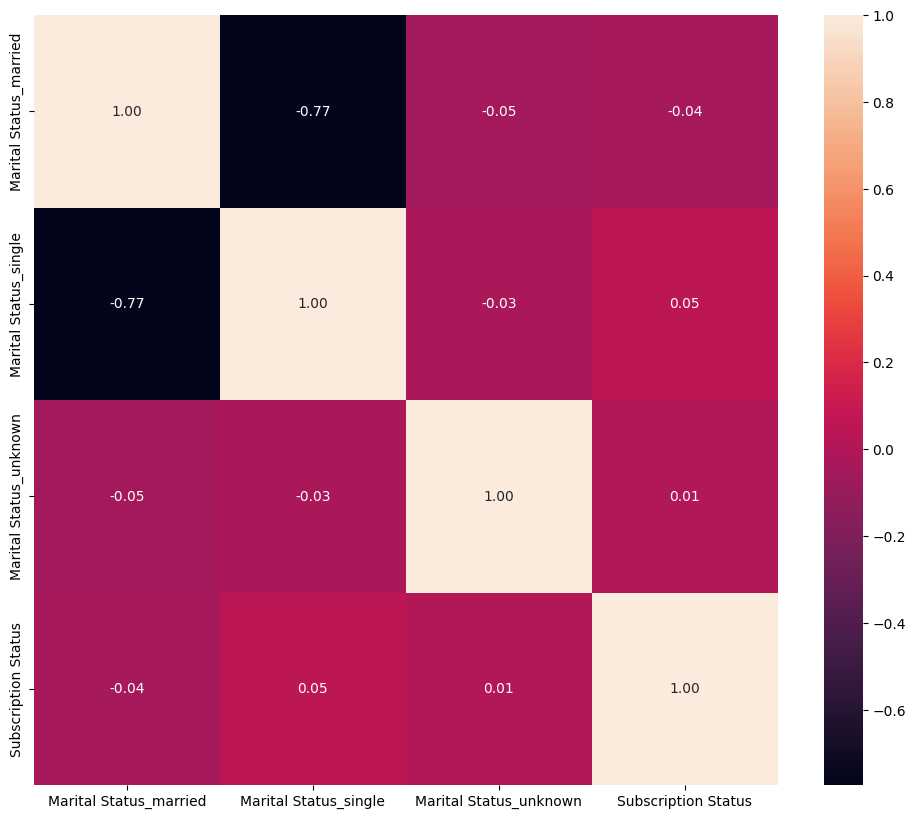

In [39]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_marital_status.corr(numeric_only=True), annot=True, fmt=".2f")

## Personal Loan

In [40]:
df_encoded_personal_loan = df_onehot.drop(columns=[col for col in df_onehot.columns if 'Personal Loan_' not in col])
df_encoded_personal_loan = pd.concat([df_encoded_personal_loan, df_onehot['Subscription Status']], axis=1)
df_encoded_personal_loan

,Personal Loan_unknown,Personal Loan_yes,Subscription Status
0,False,True,0
1,False,False,0
2,False,False,0
3,False,False,0
4,False,False,0
...,...,...,...
41183,False,False,0
41184,False,False,0
41185,False,False,1
41186,False,False,0


<Axes: >

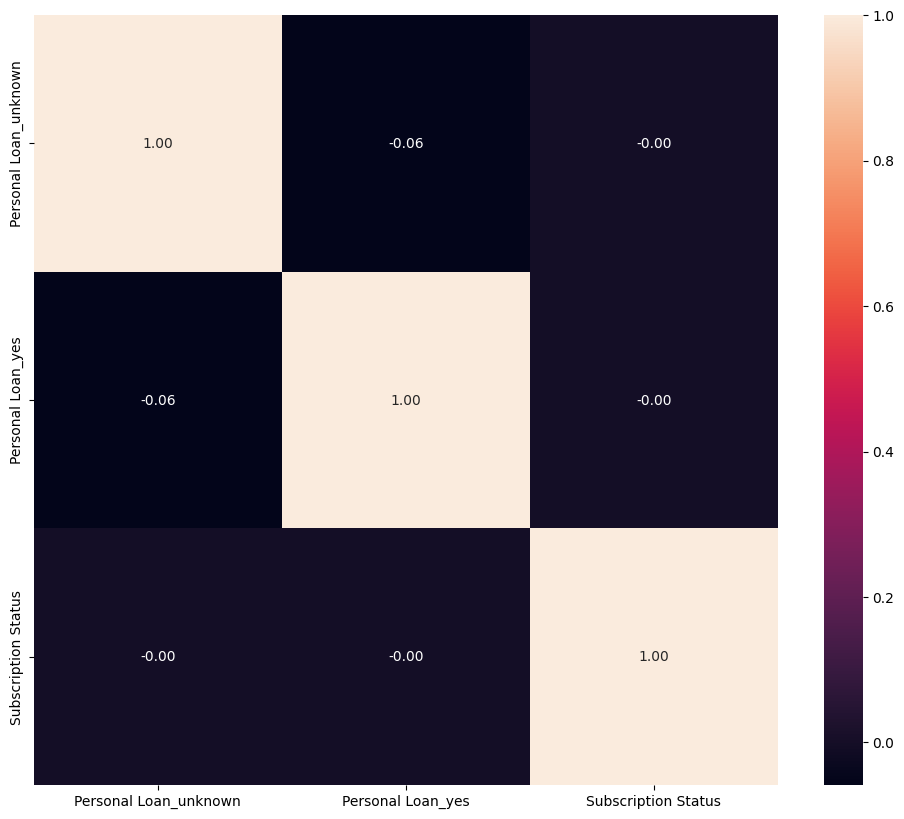

In [41]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_personal_loan.corr(numeric_only=True), annot=True, fmt=".2f")

## Campaign Calls

In [42]:
df_Campaign = df.copy()

# Convert Age column to integer
df_Campaign["Age"] = df_Campaign["Age"].apply(lambda x: int(x.split()[0]))

# Calculate median of acceptable ages
median_age = df_Campaign.loc[df_Campaign["Age"] < 100, 'Age'].median()

# Impute impossible ages with median age
df_Campaign.loc[df_Campaign["Age"] > 100, "Age"] = median_age

In [43]:
# Transform Contact Method column values into 2 distinct values
df_Campaign['Contact Method'] = df_Campaign['Contact Method'].replace({'Cell': 'cellular', 'Telephone': 'telephone'})

# Convert Housing and Personal Loan null values to 'unknown'
df_Campaign['Housing Loan'] = df_Campaign['Housing Loan'].replace({ None: "unknown" })
df_Campaign['Personal Loan'] = df_Campaign['Personal Loan'].replace({ None: "unknown" })

In [44]:
# Label encode target column
df_Campaign['Subscription Status'] = df_Campaign['Subscription Status'].replace({ "no" : 0, "yes": 1 }).astype(int)

# Drop useless ID column
df_Campaign.drop(columns=["Client ID"], inplace=True)

# Split Campaign Calls column into negative and positive values
df_Campaign_positive = df_Campaign[df_Campaign["Campaign Calls"] >= 0]
df_Campaign_negative = df_Campaign[df_Campaign["Campaign Calls"] < 0]

C:\Users\Qxiuj\AppData\Local\Temp\ipykernel_14144\2748634043.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


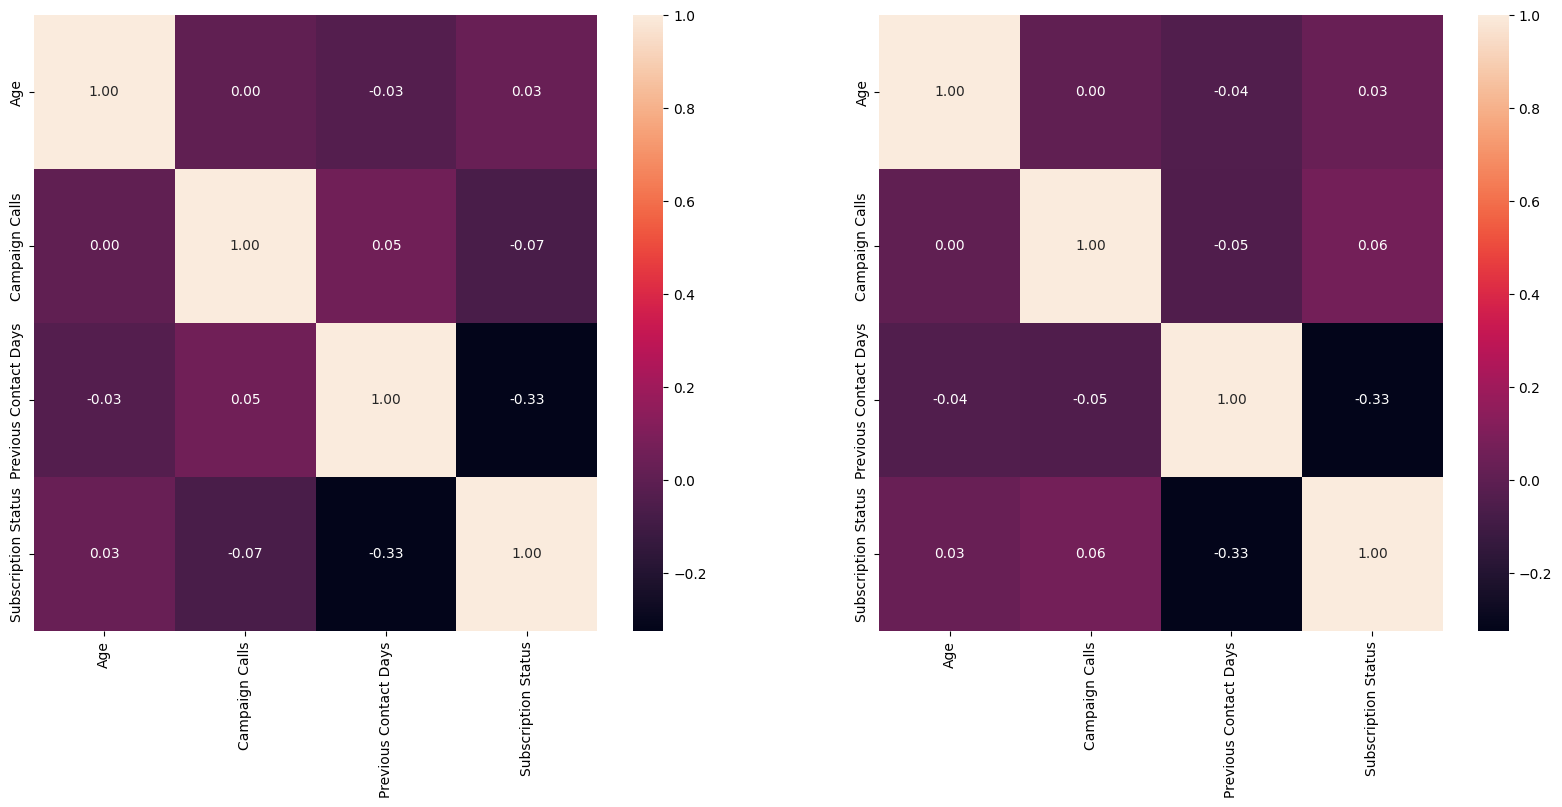

In [45]:
#
#  Compare correlation heatmap of positive and negative values to determine if negative values can be transformed into positive values
# *** Insights ****
#
# Since correlation scores for positive and negative are exactly opposite (0.05 -> -0.05, etc)
# We can transform the negative values into positive values with abs()
#

fig, ax = plt.subplots(1,2 , figsize=(20, 8))
sns.heatmap(df_Campaign_positive.corr(numeric_only=True), annot=True, fmt=".2f", ax=ax[0])
sns.heatmap(df_Campaign_negative.corr(numeric_only=True), annot=True, fmt=".2f", ax=ax[1])
fig.show()